# Machine Learning Engineer Nanodegree
## Model Evaluation & Validation
## Project: Predicting Boston Housing Prices

Welcome to the first project of the Machine Learning Engineer
### first project 
* 
read the housing dataset and show the first 5 linef 

In [1]:
# Import libraries necessary for this project
import numpy as np
import pandas as pd
import visuals as vs # Supplementary code
from sklearn.model_selection import ShuffleSplit



#### read the data saved on the same location and display it 

In [2]:

# Pretty display for notebooks
%matplotlib inline

# Load the Boston housing dataset
data = pd.read_csv('../housing.csv')


* gathering all information about dataset
* 1- type of all data
* shape of the data
* read the statistics of this data
* read the statistic of the MEDV feature and see if they are any outliers or missing values

In [3]:
#write your code here

#1- type of all data
print(data.dtypes)

# print the shape of your data
print("\nShape:", data.shape)

# display the basic statistics
print("\n", data.describe())

# display statistics of prediction column
print("\n", data['MEDV'].describe())

# missing values and duplicates
print("\nMissing values:\n", data.isnull().sum())
print("\nDuplicated rows:", data.duplicated().sum())

# outliers in MEDV using the 1.5 * IQR rule
q1, q3 = data['MEDV'].quantile([0.25, 0.75]); iqr = q3 - q1
outliers = data[(data['MEDV'] < q1 - 1.5 * iqr) | (data['MEDV'] > q3 + 1.5 * iqr)]
print("\nMEDV outliers (1.5*IQR rule): {} (above: {}, below: {})".format(
    len(outliers), (outliers['MEDV'] > data['MEDV'].median()).sum(), (outliers['MEDV'] < data['MEDV'].median()).sum()))

RM         float64
LSTAT      float64
PTRATIO    float64
MEDV       float64
dtype: object

Shape: (489, 4)

                RM       LSTAT     PTRATIO          MEDV
count  489.000000  489.000000  489.000000  4.890000e+02
mean     6.240288   12.939632   18.516564  4.543429e+05
std      0.643650    7.081990    2.111268  1.653403e+05
min      3.561000    1.980000   12.600000  1.050000e+05
25%      5.880000    7.370000   17.400000  3.507000e+05
50%      6.185000   11.690000   19.100000  4.389000e+05
75%      6.575000   17.120000   20.200000  5.187000e+05
max      8.398000   37.970000   22.000000  1.024800e+06

 count    4.890000e+02
mean     4.543429e+05
std      1.653403e+05
min      1.050000e+05
25%      3.507000e+05
50%      4.389000e+05
75%      5.187000e+05
max      1.024800e+06
Name: MEDV, dtype: float64

Missing values:
 RM         0
LSTAT      0
PTRATIO    0
MEDV       0
dtype: int64

Duplicated rows: 0

MEDV outliers (1.5*IQR rule): 22 (above: 22, below: 0)


**Observations:** 489 rows, 4 numeric (`float64`) columns, **no missing values and no duplicated rows**. The 22 `MEDV` outliers are all on the high side (expensive neighborhoods with many rooms and low `LSTAT`): they are real data, so they are **kept**.

* on the code below i assign new var for the prediction column and drop it from original dataset
* i assigne the prediction column as a price and other column as a features data

In [4]:
prices = data['MEDV']
features = data.drop('MEDV', axis = 1)
# print the shape of the data
print('Boston housing dataset has {0} data points with {1} variables each.'.format(*data.shape))

Boston housing dataset has 489 data points with 4 variables each.


## Data Exploration
In this first section of this project, you will make a cursory investigation about the Boston housing data and provide your observations. Familiarizing yourself with the data through an explorative process is a fundamental practice to help you better understand and justify your results.

Since the main goal of this project is to construct a working model which has the capability of predicting the value of houses, we will need to separate the dataset into **features** and the **target variable**. 
* The **features**, `'RM'`, `'LSTAT'`, and `'PTRATIO'`, give us quantitative information about each data point.
*  The **target variable**, `'MEDV'`, will be the variable we seek to predict. These are stored in `features` and `prices`, respectively.

### Implementation: Calculate Statistics
***
***


* claculate the statistics for the code below
* get the minimum  and the max of the price data
* get the mean
* get the median
* get the mode
* calculate the std
- need to print the data 

In [5]:
# TODO: Minimum price of the data
minimum_price = np.min(prices)

# TODO: Maximum price of the data
maximum_price = np.max(prices)

# TODO: Mean price of the data
mean_price = np.mean(prices)

# TODO: Median price of the data
median_price = np.median(prices)

# Mode price of the data
mode_price = prices.mode()[0]

# TODO: Standard deviation of prices of the data
std_price = np.std(prices)

# Show the calculated statistics
print("Statistics for Boston housing dataset:\n")
print("Minimum price: ${:,.2f}".format(minimum_price))
print("Maximum price: ${:,.2f}".format(maximum_price))
print("Mean price: ${:,.2f}".format(mean_price))
print("Median price ${:,.2f}".format(median_price))
print("Mode price ${:,.2f}".format(mode_price))
print("Standard deviation of prices: ${:,.2f}".format(std_price))

Statistics for Boston housing dataset:

Minimum price: $105,000.00
Maximum price: $1,024,800.00
Mean price: $454,342.94
Median price $438,900.00
Mode price $525,000.00
Standard deviation of prices: $165,171.13


### Question 1 - Feature Observation
As a reminder, we are using three features from the Boston housing dataset: `'RM'`, `'LSTAT'`, and `'PTRATIO'`. For each data point (neighborhood):
- `'RM'` is the average number of rooms among homes in the neighborhood.
- `'LSTAT'` is the percentage of homeowners in the neighborhood considered "lower class" (working poor).
- `'PTRATIO'` is the ratio of students to teachers in primary and secondary schools in the neighborhood.


** Using your intuition, for each of the three features above, do you think that an increase in the value of that feature would lead to an **increase** in the value of `'MEDV'` or a **decrease** in the value of `'MEDV'`? Justify your answer for each.**


## ** answer the question below **
## your answer will reflect your understand### **Answer:**
- **`RM` (rooms): an increase leads to an increase in `MEDV`.** More rooms means a bigger house, so a home with 7 rooms should be worth more than one with 6. Correlation with `MEDV` is **+0.70**.
- **`LSTAT` (% lower-class homeowners): an increase leads to a decrease in `MEDV`.** Neighborhoods with a higher share of low-income residents usually have lower property values. Correlation is **-0.76**, the strongest of the three.
- **`PTRATIO` (students per teacher): an increase leads to a decrease in `MEDV`.** A higher ratio means more crowded classrooms and weaker schools, which makes the area less attractive. Correlation is **-0.52**.


**Hint:** This problem can phrased using examples like below.  


* Would you expect a home that has an `'RM'` value(number of rooms) of 6 be worth more or less than a home that has an `'RM'` value of 7?


* Would you expect a neighborhood that has an `'LSTAT'` value(percent of lower class workers) of 15 have home prices be worth more or less than a neighborhood that has an `'LSTAT'` value of 20?


* Would you expect a neighborhood that has an `'PTRATIO'` value(ratio of students to teachers) of 10 have home prices be worth more or less than a neighborhood that has an `'PTRATIO'` value of 15?

********************************

----

## Developing a Model
In this second section of the project, you will develop the tools and techniques necessary for a model to make a prediction. Being able to make accurate evaluations of each model's performance through the use of these tools and techniques helps to greatly reinforce the confidence in your predictions.

## takecare for this part to focus for every stage

*****************************
**************************

*****************************************
********************************************

## R2 Score

### Implementation: Define a Performance Metric
- It is difficult to measure the quality of a given model without quantifying its performance over training and testing.
- This is typically done using some type of performance metric, whether it is through calculating some type of error, the goodness of fit, or some other useful measurement.
-  For this project, you will be calculating the [*coefficient of determination*](http://stattrek.com/statistics/dictionary.aspx?definition=coefficient_of_determination), R<sup>2</sup>, to quantify your model's performance.
-  The coefficient of determination for a model is a useful statistic in regression analysis, as it often describes how "good" that model is at making predictions. 
******************************************


The values for R<sup>2</sup> range from 0 to 1, which captures the percentage of squared correlation between the predicted and actual values of the **target variable**. 
************************************
A model with an R<sup>2</sup> of 0 is no better than a model that always predicts the *mean* of the target variable, whereas a model with an R<sup>2</sup> of 1 perfectly predicts the target variable. 

Any value between 0 and 1 indicates what percentage of the target variable, using this model, can be explained by the **features**. _A model can be given a negative R<sup>2</sup> as well, which indicates that the model is **arbitrarily worse** than one that always predicts the mean of the target variable.

******************************************
For the `performance_metric` function in the code cell below, you will need to implement the following:
- Use `r2_score` from `sklearn.metrics` to perform a performance calculation between `y_true` and `y_predict`.
- Assign the performance score to the `score` variable.

In [6]:
# TODO: Import 'r2_score'
from sklearn.metrics import r2_score

def performance_metric(y_test, y_predict):
    """ Calculates and returns the performance score between 
        test and predicted values based on the metric chosen. """
    
    # TODO: Calculate the performance score between 'y_test' and 'y_predict'
    score = r2_score(y_test, y_predict)
    
    # Return the score
    return score

### Question 2 - Goodness of Fit
Assume that a dataset contains five data points and a model made the following predictions for the target variable:

| True Value | Prediction |
| :-------------: | :--------: |
| 3.0 | 2.5 |
| -0.5 | 0.0 |
| 2.0 | 2.1 |
| 7.0 | 7.8 |
| 4.2 | 5.3 |

Run the code cell below to use the `performance_metric` function and calculate this model's coefficient of determination.

In [7]:
# Calculate the performance of this model
score = performance_metric([3, -0.5, 2, 7, 4.2], [2.5, 0.0, 2.1, 7.8, 5.3])
print ("Model has a coefficient of determination, R^2, of {:.3f}.".format(score))

Model has a coefficient of determination, R^2, of 0.923.


* Would you consider this model to have successfully captured the variation of the target variable? 
* Why or why not?

** Hint: **  The R2 score is the proportion of the variance in the dependent variable that is predictable from the independent variable. In other words:
* R2 score of 0 means that the dependent variable cannot be predicted from the independent variable.
* R2 score of 1 means the dependent variable can be predicted from the independent variable.
* R2 score between 0 and 1 indicates the extent to which the dependent variable is predictable. An 
* R2 score of 0.40 means that 40 percent of the variance in Y is predictable from X.

### **Answer:**

R² = **0.923**, so about 92% of the variance of the target is explained by the model. Yes, it successfully captured the variation: R² is close to 1 and each prediction is close to the true value (but with only 5 points the conclusion is just indicative).

### Implementation: Shuffle and Split Data
- Your next implementation requires that you take the Boston housing dataset and split the data into training and testing subsets.
-  Typically, the data is also shuffled into a random order when creating the training and testing subsets to remove any bias in the ordering of the dataset.

For the code cell below, you will need to implement the following:
- Use `train_test_split` from `sklearn.cross_validation` to shuffle and split the `features` and `prices` data into training and testing sets.
  - Split the data into 80% training and 20% testing.
  - Set the `random_state` for `train_test_split` to a value of your choice. This ensures results are consistent.
- Assign the train and testing splits to `X_train`, `X_test`, `y_train`, and `y_test`.

In [8]:
# TODO: Import 'train_test_split'
from sklearn.model_selection import train_test_split

# TODO: Shuffle and split the data into training and testing subsets
X_train, X_test, y_train, y_test = train_test_split(features, prices, test_size=0.2, random_state=1)

# Success
print("Training and testing split was successful.")

Training and testing split was successful.


### Question 3 - Training and Testing

* What is the benefit to splitting a dataset into some ratio of training and testing subsets for a learning algorithm?

**Hint:** Think about how overfitting or underfitting is contingent upon how splits on data is done.

### **Answer:**

Splitting lets us **train on one part and evaluate on data the model has never seen**, which gives an honest estimate of how it will do on new houses. Without a test set, a model can memorize the training data (overfitting) and we would not notice. Shuffling before the split removes any bias caused by the ordering of the rows.

----

## Analyzing Model Performance
In this third section of the project, you'll take a look at several models' learning and testing performances on various subsets of training data. Additionally, you'll investigate one particular algorithm with an increasing `'max_depth'` parameter on the full training set to observe how model complexity affects performance. Graphing your model's performance based on varying criteria can be beneficial in the analysis process, such as visualizing behavior that may not have been apparent from the results alone.

### Learning Curves
The following code cell produces four graphs for a decision tree model with different maximum depths. Each graph visualizes the learning curves of the model for both training and testing as the size of the training set is increased. Note that the shaded region of a learning curve denotes the uncertainty of that curve (measured as the standard deviation). The model is scored on both the training and testing sets using R<sup>2</sup>, the coefficient of determination.  

Run the code cell below and use these graphs to answer the following question.

In [9]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import learning_curve, ShuffleSplit, train_test_split
from sklearn.tree import DecisionTreeRegressor

# Suppress matplotlib user warnings
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")

# Display inline matplotlib plots with IPython
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'inline')

def ModelLearning(X, y):
    """Calculates the performance of several models with varying sizes of training data.
       The learning and testing scores for each model are then plotted."""
    
    # Create 10 cross-validation sets for training and testing
    cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=0)

    # Generate the training set sizes increasing by 50
    train_sizes = np.rint(np.linspace(1, X.shape[0] * 0.8 - 1, 9)).astype(int)

    # Create the figure window
    fig, axes = plt.subplots(2, 2, figsize=(10, 7))

    # Create four different models based on max_depth
    for k, depth in enumerate([1, 3, 6, 10]):
        # Create a Decision tree regressor at max_depth = depth
        regressor = DecisionTreeRegressor(max_depth=depth)

        # Calculate the training and testing scores
        sizes, train_scores, test_scores = learning_curve(
            regressor, X, y, cv=cv, train_sizes=train_sizes, scoring='r2'
        )
        
        # Find the mean and standard deviation for smoothing
        train_mean = np.mean(train_scores, axis=1)
        train_std = np.std(train_scores, axis=1)
        test_mean = np.mean(test_scores, axis=1)
        test_std = np.std(test_scores, axis=1)

        # Subplot the learning curve 
        ax = axes[k//2, k%2]
        ax.plot(sizes, train_mean, 'o-', color='r', label='Training Score')
        ax.plot(sizes, test_mean, 'o-', color='g', label='Testing Score')
        ax.fill_between(sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='r')
        ax.fill_between(sizes, test_mean - test_std, test_mean + test_std, alpha=0.15, color='g')
        
        # Labels
        ax.set_title(f'max_depth = {depth}')
        ax.set_xlabel('Number of Training Points')
        ax.set_ylabel('Score')
        ax.set_xlim([0, X.shape[0] * 0.8])
        ax.set_ylim([-0.05, 1.05])
        ax.legend(loc='lower right')
    
    # Visual aesthetics
    fig.suptitle('Decision Tree Regressor Learning Performances', fontsize=16, y=1.03)
    fig.tight_layout()
    plt.show()



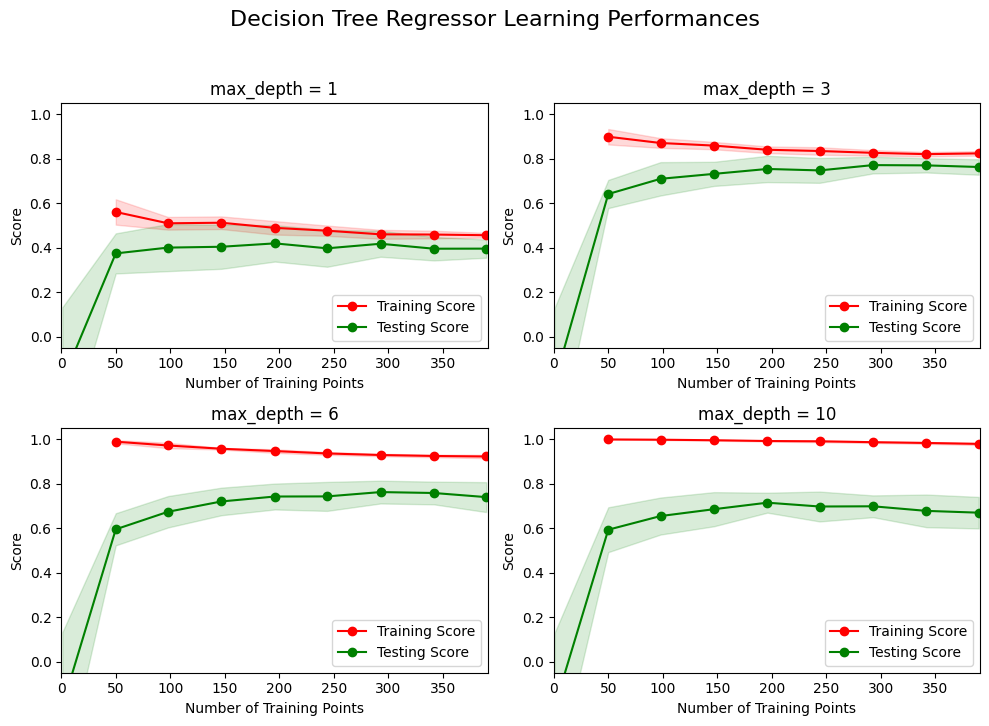

In [10]:
# Produce learning curves for varying training set sizes and maximum depths
ModelLearning(features, prices)

### Question 4 - Learning the Data
* Choose one of the graphs above and state the maximum depth for the model. 
* What happens to the score of the training curve as more training points are added? What about the testing curve? 
* Would having more training points benefit the model? 

**Hint:** Are the learning curves converging to particular scores? Generally speaking, the more data you have, the better. But if your training and testing curves are converging with a score above your benchmark threshold, would this be necessary?
Think about the pros and cons of adding more training points based on if the training and testing curves are converging.

### **Answer:**

Taking the graph with **`max_depth = 3`**: as training points are added, the **training score decreases** (about 0.90 with a small sample down to ≈0.83, since a fixed-depth tree cannot fit more and more points perfectly) while the **testing score increases** (from ≈0.65 to ≈0.76). The two curves are getting closer (gap ≈0.06), so the model generalizes reasonably well.

More training points would give only a **small extra benefit**: the testing curve is flattening, and the limit is the model's simplicity, not the data size. For `max_depth = 1` both curves converge to a low score (≈0.45 / ≈0.40), so more data would not help at all (high bias). For `max_depth = 10` the training score stays near 1 and the gap stays large (overfitting), so more data could help but the model is too complex.

### Complexity Curves
The following code cell produces a graph for a decision tree model that has been trained and validated on the training data using different maximum depths. The graph produces two complexity curves — one for training and one for validation. Similar to the **learning curves**, the shaded regions of both the complexity curves denote the uncertainty in those curves, and the model is scored on both the training and validation sets using the `performance_metric` function.  

** Run the code cell below and use this graph to answer the following two questions Q5 and Q6. **

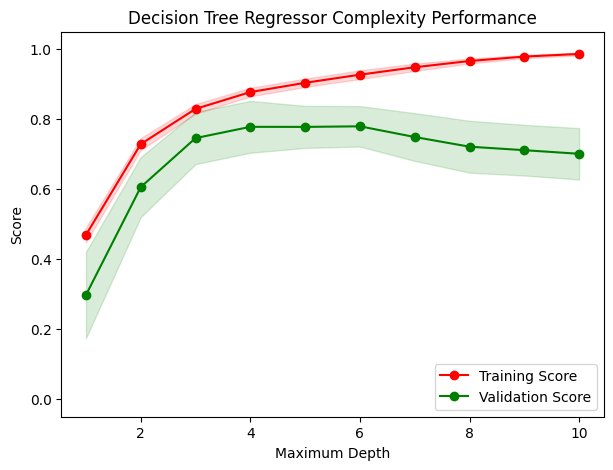

In [11]:
vs.ModelComplexity(X_train, y_train)

### Question 5 - Bias-Variance Tradeoff
* When the model is trained with a maximum depth of 1, does the model suffer from high bias or from high variance? 
* How about when the model is trained with a maximum depth of 10? What visual cues in the graph justify your conclusions?

**Hint:** High bias is a sign of underfitting(model is not complex enough to pick up the nuances in the data) and high variance is a sign of overfitting(model is by-hearting the data and cannot generalize well). Think about which model(depth 1 or 10) aligns with which part of the tradeoff.

### **Answer:**

- **`max_depth = 1` → high bias (underfitting).** Both the training score (≈0.47) and the validation score (≈0.30) are low: the model is too simple to capture the pattern.
- **`max_depth = 10` → high variance (overfitting).** The training score is ≈0.99 but the validation score is only ≈0.70. The big gap between the two curves, and the fact that the validation score goes *down* after depth 6 while the training score keeps going up, show that the model is memorizing the training data.

### Question 6 - Best-Guess Optimal Model
* Which maximum depth do you think results in a model that best generalizes to unseen data? 
* What intuition lead you to this answer?

** Hint: ** Look at the graph above Question 5 and see where the validation scores lie for the various depths that have been assigned to the model. Does it get better with increased depth? At what point do we get our best validation score without overcomplicating our model? And remember, Occams Razor states "Among competing hypotheses, the one with the fewest assumptions should be selected."

### **Answer:**

**`max_depth = 4`.** The validation score rises quickly up to depth 4 (≈0.78) and then stays flat until depth 6 (0.778 at depth 4 and 5, 0.780 at depth 6) before it declines. The training/validation gap is still moderate at depth 4, while it widens as depth increases. By Occam's razor we prefer the simplest model that gives the best validation score.

-----

## Evaluating Model Performance
In this final section of the project, you will construct a model and make a prediction on the client's feature set using an optimized model from `fit_model`.

### Question 7 - Cross-Validation

* What is the k-fold cross-validation training technique? 

* What benefit does this technique provide for grid search when optimizing a model?

**Hint:** When explaining the k-fold cross validation technique, be sure to touch upon what 'k' is, how the dataset is split into different parts for training and testing and the number of times it is run based on the 'k' value.

When thinking about how k-fold cross validation helps grid search, think about the main drawbacks of grid search which are hinged upon **using a particular subset of data for training or testing** and how k-fold cv could help alleviate that. You can refer to the [docs](http://scikit-learn.org/stable/modules/cross_validation.html#cross-validation) for your answer.

###   **Answer:**

**k-fold cross-validation** splits the training data into *k* equal folds. The model is trained *k* times; each time *k-1* folds are used for training and the remaining fold for validation, so every point is used for validation exactly once, and the *k* scores are averaged.

For grid search this means every hyper-parameter combination (e.g. each `max_depth`) is judged on **several different train/validation splits** instead of one split that may be lucky or unlucky. This gives a more reliable choice of parameters and makes efficient use of limited data. (This project uses `ShuffleSplit`, which makes 10 random 80/20 splits: a similar idea.)

### Implementation: Fitting a Model
Your final implementation requires that you bring everything together and train a model using the **decision tree algorithm**. To ensure that you are producing an optimized model, you will train the model using the grid search technique to optimize the `'max_depth'` parameter for the decision tree. The `'max_depth'` parameter can be thought of as how many questions the decision tree algorithm is allowed to ask about the data before making a prediction. Decision trees are part of a class of algorithms called *supervised learning algorithms*.

In addition, you will find your implementation is using `ShuffleSplit()` for an alternative form of cross-validation (see the `'cv_sets'` variable). While it is not the K-Fold cross-validation technique you describe in **Question 8**, this type of cross-validation technique is just as useful!. The `ShuffleSplit()` implementation below will create 10 (`'n_splits'`) shuffled sets, and for each shuffle, 20% (`'test_size'`) of the data will be used as the *validation set*. While you're working on your implementation, think about the contrasts and similarities it has to the K-fold cross-validation technique.

Please note that ShuffleSplit has different parameters in scikit-learn versions 0.17 and 0.18.
For the `fit_model` function in the code cell below, you will need to implement the following:
- Use [`DecisionTreeRegressor`](http://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html) from `sklearn.tree` to create a decision tree regressor object.
  - Assign this object to the `'regressor'` variable.
- Create a dictionary for `'max_depth'` with the values from 1 to 10, and assign this to the `'params'` variable.
- Use [`make_scorer`](http://scikit-learn.org/stable/modules/generated/sklearn.metrics.make_scorer.html) from `sklearn.metrics` to create a scoring function object.
  - Pass the `performance_metric` function as a parameter to the object.
  - Assign this scoring function to the `'scoring_fnc'` variable.
- Use [`GridSearchCV`](http://scikit-learn.org/0.17/modules/generated/sklearn.grid_search.GridSearchCV.html) from `sklearn.grid_search` to create a grid search object.
  - Pass the variables `'regressor'`, `'params'`, `'scoring_fnc'`, and `'cv_sets'` as parameters to the object. 
  - Assign the `GridSearchCV` object to the `'grid'` variable.

In [12]:
# TODO: Import 'make_scorer', 'DecisionTreeRegressor', and 'GridSearchCV'
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import make_scorer
from sklearn.model_selection import GridSearchCV   # (old versions: sklearn.grid_search)

def fit_model(X, y):
    """ Performs grid search over the 'max_depth' parameter for a 
        decision tree regressor trained on the input data [X, y]. """
    
    # Create cross-validation sets from the training data
    cv_sets = ShuffleSplit(n_splits = 10, test_size = 0.20, random_state = 0)

    # TODO: Create a decision tree regressor object
    regressor = DecisionTreeRegressor(random_state = 0)

    # TODO: Create a dictionary for the parameter 'max_depth' with a range from 1 to 10
    params = {'max_depth': list(range(1,11))}

    # TODO: Transform 'performance_metric' into a scoring function using 'make_scorer' 
    scoring_fnc = make_scorer(performance_metric)

    # TODO: Create the grid search object
    grid = GridSearchCV(regressor, params, scoring = scoring_fnc, cv = cv_sets)

    # Fit the grid search object to the data to compute the optimal model
    grid = grid.fit(X, y)

    # Return the optimal model after fitting the data
    return grid.best_estimator_

### Question 9 - Optimal Model

* What maximum depth does the optimal model have? How does this result compare to your guess in **Question 6**?  

Run the code block below to fit the decision tree regressor to the training data and produce an optimal model.

In [13]:
# Fit the training data to the model using grid search
reg = fit_model(X_train, y_train)

# Produce the value for 'max_depth'
print("Parameter 'max_depth' is {} for the optimal model.".format(reg.get_params()['max_depth']))
print("R2 on the test set: {:.4f}".format(performance_metric(y_test, reg.predict(X_test))))

Parameter 'max_depth' is 6 for the optimal model.
R2 on the test set: 0.7878


** Hint: ** The answer comes from the output of the code snipped above.

### **Answer: ** 

### **Answer:**

The optimal model has **`max_depth = 6`** (cross-validation R² ≈ 0.78, test R² ≈ 0.79). My guess in Question 6 was 4. The validation scores of depths 4, 5 and 6 are practically equal (0.778 / 0.778 / 0.780), so the guess was close; the grid search just picked the highest of the three.

### Question 10 - Predicting Selling Prices
Imagine that you were a real estate agent in the Boston area looking to use this model to help price homes owned by your clients that they wish to sell. You have collected the following information from three of your clients:

| Feature | Client 1 | Client 2 | Client 3 |
| :---: | :---: | :---: | :---: |
| Total number of rooms in home | 5 rooms | 4 rooms | 8 rooms |
| Neighborhood poverty level (as %) | 17% | 32% | 3% |
| Student-teacher ratio of nearby schools | 15-to-1 | 22-to-1 | 12-to-1 |

* What price would you recommend each client sell his/her home at? 
* Do these prices seem reasonable given the values for the respective features? 

**Hint:** Use the statistics you calculated in the **Data Exploration** section to help justify your response.  Of the three clients, client 3 has has the biggest house, in the best public school neighborhood with the lowest poverty level; while client 2 has the smallest house, in a neighborhood with a relatively high poverty rate and not the best public schools.

Run the code block below to have your optimized model make predictions for each client's home.

In [14]:
# Produce a matrix for client data  (values taken from the table above: RM, LSTAT, PTRATIO;
# the original cell had 34 / 55 / 7 for LSTAT, which does not match the table)
client_data = [[5, 17, 15], # Client 1
               [4, 32, 22], # Client 2
               [8, 3, 12]]  # Client 3

# Show predictions
for i, price in enumerate(reg.predict(client_data)):
    print("Predicted selling price for Client {}'s home: ${:,.2f}".format(i+1, price))

Predicted selling price for Client 1's home: $424,935.00
Predicted selling price for Client 2's home: $284,200.00
Predicted selling price for Client 3's home: $933,975.00


### **Answer:**

| Client | Home | Predicted price (decision tree, depth 6) |
|---|---|---|
| 1 | 5 rooms, 17 % poverty, 15:1 | ≈ **\$424,900** |
| 2 | 4 rooms, 32 % poverty, 22:1 | ≈ **\$284,200** |
| 3 | 8 rooms, 3 % poverty, 12:1 | ≈ **\$934,000** |

The prices are reasonable and ordered as expected. Client 3 (biggest house, richest neighborhood, best schools) is the highest and close to the top of the dataset (max \$1,024,800). Client 2 (smallest house, highest poverty, most crowded schools) is the lowest, well below the mean (\$454,343) and near the bottom of the dataset (min \$105,000). Client 1 is a bit below the mean, which fits an average-sized house in a middling neighborhood.

**Caveats:** a decision tree returns the *average of a leaf*, so its predictions are step-like (two different clients that land in the same leaf get exactly the same price). Client 3's `PTRATIO` = 12 is slightly outside the training range (12.6 to 22) and Client 2's `RM` = 4 is at the low edge, so those two predictions are mild extrapolations. The typical error of the model is about ±\$55k to ±\$75k.

----
## Extra: which model gives the best result?

The assignment asks for a decision tree, but is it the best choice? Below, **trees and non-tree models** are compared with **nested cross-validation**: the outer loop (10 random 80/20 splits of the *whole* dataset) measures performance on data never used for tuning, while the inner loop (3 splits, `GridSearchCV`) tunes the hyper-parameters of each model. This is a fairer comparison than a single test split of only 98 houses. (Takes about 1 to 2 minutes to run.)

In [15]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.compose import TransformedTargetRegressor

def scaled_target(p):
    return TransformedTargetRegressor(regressor=p, transformer=StandardScaler())

candidates = {
  'Linear Regression':     (Pipeline([('s', StandardScaler()), ('m', LinearRegression())]), {}),
  'Poly + Ridge':          (Pipeline([('s', StandardScaler()), ('p', PolynomialFeatures(include_bias=False)), ('s2', StandardScaler()), ('m', Ridge())]),
                            {'p__degree': [1, 2, 3], 'm__alpha': [0.1, 1, 10, 100, 300]}),
  'KNN':                   (Pipeline([('s', StandardScaler()), ('m', KNeighborsRegressor())]),
                            {'m__n_neighbors': list(range(3, 26, 2)), 'm__weights': ['uniform', 'distance']}),
  'SVR (RBF)':             (scaled_target(Pipeline([('s', StandardScaler()), ('m', SVR())])),
                            {'regressor__m__C': [0.3, 1, 3, 10, 30], 'regressor__m__gamma': [0.03, 0.1, 0.3, 1], 'regressor__m__epsilon': [0.05, 0.1, 0.2]}),
  'Decision Tree':         (DecisionTreeRegressor(random_state=0), {'max_depth': list(range(1, 11))}),
  'Random Forest':         (RandomForestRegressor(n_estimators=100, random_state=0), {'max_depth': [4, 6, 8, None], 'min_samples_leaf': [1, 3, 5]}),
  'Extra Trees':           (ExtraTreesRegressor(n_estimators=100, random_state=0), {'max_depth': [4, 6, 8, None], 'min_samples_leaf': [1, 3, 5]}),
  'Gradient Boosting':     (GradientBoostingRegressor(random_state=0), {'n_estimators': [100, 200], 'learning_rate': [0.03, 0.1], 'max_depth': [2, 3], 'subsample': [0.8]}),
}

outer_cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
inner_cv = ShuffleSplit(n_splits=3, test_size=0.2, random_state=0)

fold_scores = {}
for name, (estimator, grid) in candidates.items():
    search = GridSearchCV(estimator, grid, cv=inner_cv, scoring='r2')
    fold_scores[name] = cross_val_score(search, features, prices, cv=outer_cv, scoring='r2')

summary = pd.DataFrame({n: {'mean R2': s.mean(), 'std': s.std()} for n, s in fold_scores.items()}).T
summary = summary.sort_values('mean R2', ascending=False).round(4)
summary

,mean R2,std
Extra Trees,0.8512,0.0175
SVR (RBF),0.8416,0.0250
Random Forest,0.8414,0.0184
Poly + Ridge,0.8323,0.0340
Gradient Boosting,0.8303,0.0202
KNN,0.8186,0.0227
Decision Tree,0.7940,0.0430
Linear Regression,0.7174,0.0388


Extra Trees - SVR (RBF): mean diff = +0.0095, std = 0.0110, Extra Trees wins in 7 of 10 splits
Extra Trees - Decision Tree: mean diff = +0.0571, wins in 10 of 10 splits


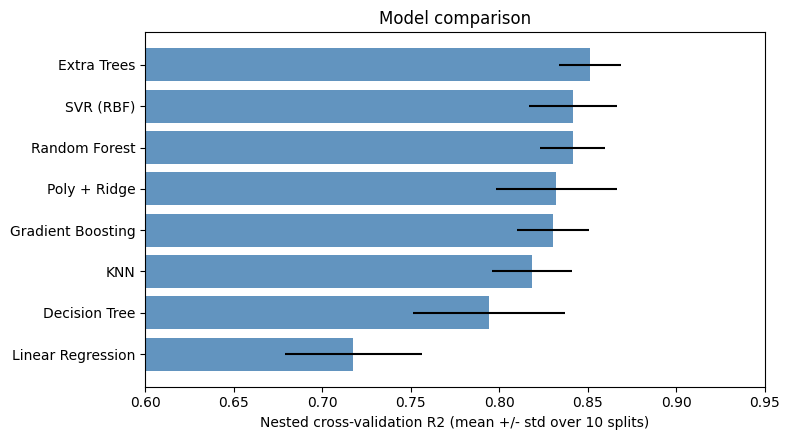

In [16]:
plt.figure(figsize=(8, 4.5))
order = summary.index[::-1]
plt.barh(order, summary.loc[order, 'mean R2'], xerr=summary.loc[order, 'std'], color='steelblue', alpha=.85)
plt.xlabel('Nested cross-validation R2 (mean +/- std over 10 splits)')
plt.xlim(0.6, 0.95); plt.title('Model comparison'); plt.tight_layout(); plt.show()

# paired comparison of the top models on the SAME 10 outer splits
best, second = summary.index[0], summary.index[1]
diff = fold_scores[best] - fold_scores[second]
print("{} - {}: mean diff = {:+.4f}, std = {:.4f}, {} wins in {} of 10 splits".format(
    best, second, diff.mean(), diff.std(), best, int((diff > 0).sum())))
dt_diff = fold_scores[best] - fold_scores['Decision Tree']
print("{} - Decision Tree: mean diff = {:+.4f}, wins in {} of 10 splits".format(best, dt_diff.mean(), int((dt_diff > 0).sum())))

### Conclusion

| Model | Nested CV R² (mean ± std) |
|---|---|
| **Extra Trees** | **0.851 ± 0.018** |
| SVR (RBF) | 0.842 ± 0.025 |
| Random Forest | 0.841 ± 0.018 |
| Poly + Ridge | 0.832 ± 0.034 |
| Gradient Boosting | 0.830 ± 0.020 |
| KNN | 0.819 ± 0.023 |
| Decision Tree (the assignment's model) | 0.794 ± 0.043 |
| Linear Regression | 0.717 ± 0.039 |

- **The best result is Extra Trees (R² ≈ 0.85).** It beats the single decision tree by about **+0.057 R²** and wins in **all 10 splits**, and its errors are also more stable (std 0.018 vs 0.043).
- The gap between the top three (Extra Trees, SVR, Random Forest) is **small** (+0.0095 vs SVR, with a std of 0.011, and Extra Trees wins 7 of 10 splits), so they should be considered practically tied; the choice between them can be made on simplicity, speed and model size.
- A single decision tree is clearly better than Linear Regression (the relationship is non-linear) but worse than ensembles of trees and than SVR: one tree is unstable and over-fits, and averaging many randomized trees reduces the variance.
- The decision tree is still the right answer for **this assignment** (it is what the questions ask for, and it is easy to explain). For the **best predictions**, use Extra Trees (or SVR if you want a very small model file).